# Modul 6 — Machine Learning Supervised, Regresi (CRISP-DM Penuh)
## Convergeni Data Consulting (CDC) — Klien: PT Komponen Jaya

Notebook ini menjalankan seluruh pipeline CRISP-DM Modul 6: data batch produksi
sintetis, regresi linear, MAE/RMSE/R2 vs baseline naif, dan dua demonstrasi
data leakage (prosedural dan fitur).

## Data dan Model Dasar

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

np.random.seed(42)
n = 600
pabrik = np.random.choice(["Pabrik Cikarang", "Pabrik Karawang", "Pabrik Bekasi"], size=n, p=[0.45, 0.35, 0.20])
shift = np.random.choice(["Pagi", "Siang", "Malam"], size=n, p=[0.35, 0.35, 0.30])
suhu_mesin_c = np.clip(np.random.normal(78, 6, n), 60, 100)
tekanan_hidrolik_bar = np.clip(np.random.normal(145, 12, n), 100, 180)
kecepatan_unit_jam = np.clip(np.random.normal(320, 40, n), 200, 450)
usia_mesin_tahun = np.clip(np.random.exponential(4, n), 0.2, 18)
pengalaman_operator_tahun = np.clip(np.random.exponential(5, n), 0.1, 25)
efek_shift = np.where(shift == "Malam", 0.6, np.where(shift == "Siang", 0.15, 0.0))
efek_pabrik = np.where(pabrik == "Pabrik Bekasi", 0.5, np.where(pabrik == "Pabrik Karawang", 0.1, 0.0))
deviasi_suhu = np.abs(suhu_mesin_c - 75)
noise = np.random.normal(0, 0.5, n)
tingkat_cacat_persen = np.clip(
    0.8 + 0.05 * deviasi_suhu + 0.10 * usia_mesin_tahun
    + 0.004 * np.clip(kecepatan_unit_jam - 300, 0, None)
    - 0.07 * pengalaman_operator_tahun + efek_shift + efek_pabrik + noise, 0.1, None)
jumlah_retur_pelanggan = np.clip(tingkat_cacat_persen * 8.5 + np.random.normal(0, 2, n), 0, None).round().astype(int)

df = pd.DataFrame({"pabrik": pabrik, "shift": shift, "suhu_mesin_c": suhu_mesin_c.round(1),
    "tekanan_hidrolik_bar": tekanan_hidrolik_bar.round(1), "kecepatan_unit_jam": kecepatan_unit_jam.round(0),
    "usia_mesin_tahun": usia_mesin_tahun.round(2), "pengalaman_operator_tahun": pengalaman_operator_tahun.round(2),
    "jumlah_retur_pelanggan": jumlah_retur_pelanggan, "tingkat_cacat_persen": tingkat_cacat_persen.round(3)})

fitur_numerik = ["suhu_mesin_c", "tekanan_hidrolik_bar", "kecepatan_unit_jam", "usia_mesin_tahun", "pengalaman_operator_tahun"]
fitur_kategorikal = ["pabrik", "shift"]
target = "tingkat_cacat_persen"
X = df[fitur_numerik + fitur_kategorikal]
y = df[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

preprocessor = ColumnTransformer([("num", StandardScaler(), fitur_numerik), ("cat", OneHotEncoder(drop="first"), fitur_kategorikal)])
pipeline = Pipeline([("preprocessor", preprocessor), ("model", LinearRegression())])
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

baseline_pred = np.full(len(y_test), y_train.mean())
mae_baseline = mean_absolute_error(y_test, baseline_pred)
print(f"Model:    MAE={mae:.4f}, RMSE={rmse:.4f}, R2={r2:.4f}")
print(f"Baseline: MAE={mae_baseline:.4f}")

Model:    MAE=0.4443, RMSE=0.5672, R2=0.4783
Baseline: MAE=0.6278


## Visualisasi 1: Model vs Baseline Naif dan Prediksi vs Aktual (Asset Baru)

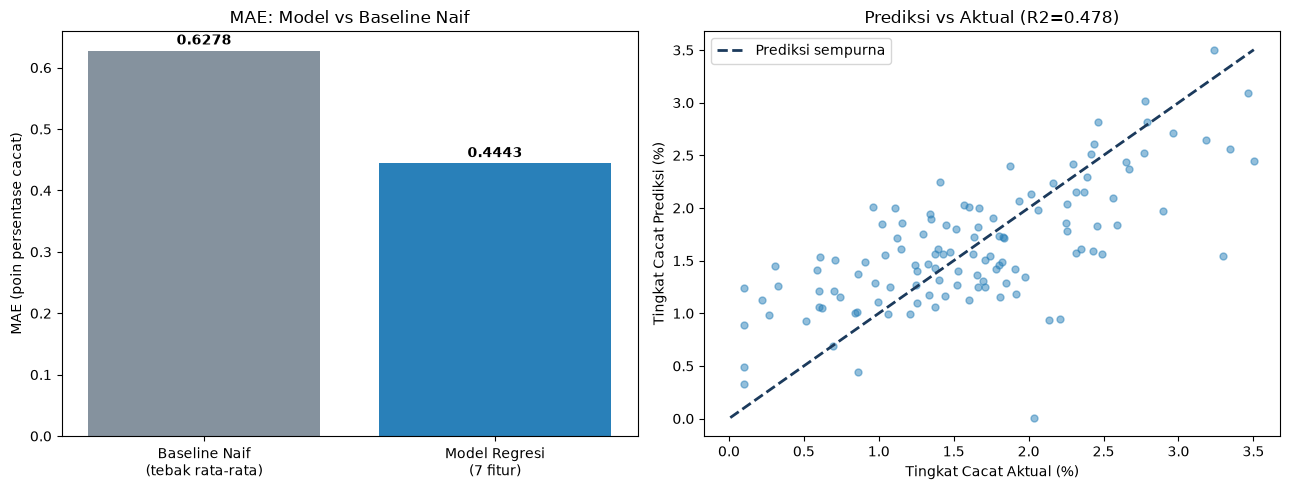

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(["Baseline Naif\n(tebak rata-rata)", "Model Regresi\n(7 fitur)"], [mae_baseline, mae], color=["#85929E", "#2980B9"])
axes[0].set_ylabel("MAE (poin persentase cacat)")
axes[0].set_title("MAE: Model vs Baseline Naif")
for i, v in enumerate([mae_baseline, mae]):
    axes[0].text(i, v + 0.01, f"{v:.4f}", ha="center", fontweight="bold")

axes[1].scatter(y_test, y_pred, alpha=0.5, color="#2980B9", s=25)
lim = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[1].plot(lim, lim, color="#1B3A5C", linestyle="--", linewidth=2, label="Prediksi sempurna")
axes[1].set_xlabel("Tingkat Cacat Aktual (%)")
axes[1].set_ylabel("Tingkat Cacat Prediksi (%)")
axes[1].set_title(f"Prediksi vs Aktual (R2={r2:.3f})")
axes[1].legend()

plt.tight_layout()
plt.savefig("modul06_baseline_dan_prediksi.png", dpi=150, bbox_inches="tight")
plt.show()

## Visualisasi 2: Dua Jenis Data Leakage, R2 Berdampingan (Asset Baru, mengganti M06-01 & M06-02)

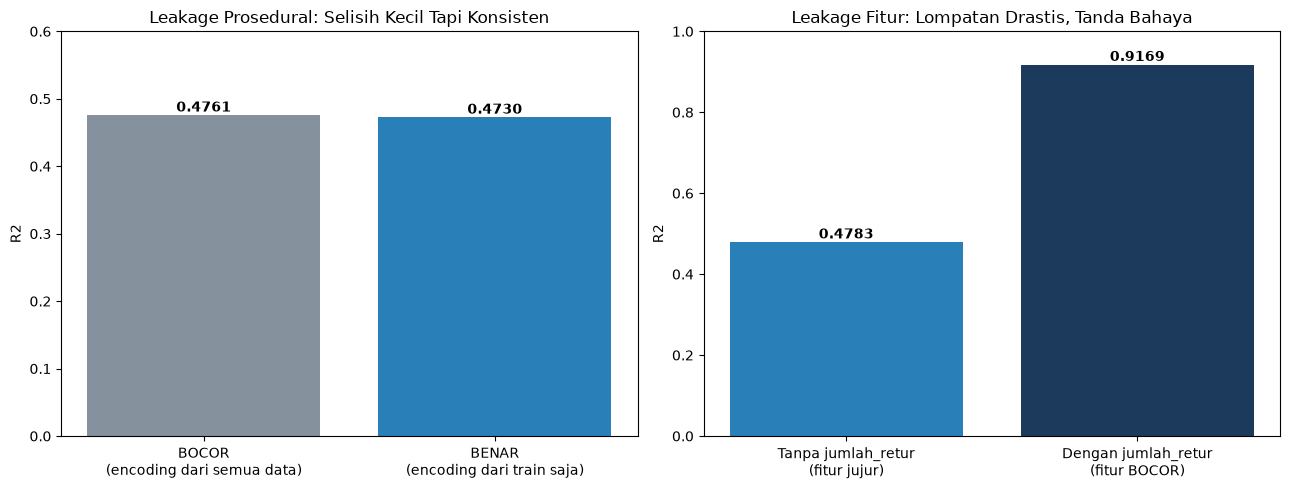

Prosedural: bocor=0.4761 vs benar=0.4730
Fitur: jujur=0.4783 vs bocor=0.9169


In [3]:
# Leakage prosedural: target encoding dari SELURUH data (bocor) vs dari TRAIN saja (benar)
df_bocor = df.copy()
df_bocor["pabrik_encoded"] = df_bocor.groupby("pabrik")[target].transform("mean")
df_bocor["shift_encoded"] = df_bocor.groupby("shift")[target].transform("mean")
X_bocor = df_bocor[fitur_numerik + ["pabrik_encoded", "shift_encoded"]]
Xb_train, Xb_test, yb_train, yb_test = train_test_split(X_bocor, y, test_size=0.2, random_state=42)
model_bocor = LinearRegression().fit(Xb_train, yb_train)
r2_bocor = r2_score(yb_test, model_bocor.predict(Xb_test))

peta_pabrik = y_train.groupby(X_train["pabrik"]).mean()
peta_shift = y_train.groupby(X_train["shift"]).mean()
X_train_benar = X_train.copy()
X_train_benar["pabrik_encoded"] = X_train_benar["pabrik"].map(peta_pabrik)
X_train_benar["shift_encoded"] = X_train_benar["shift"].map(peta_shift)
X_test_benar = X_test.copy()
X_test_benar["pabrik_encoded"] = X_test_benar["pabrik"].map(peta_pabrik)
X_test_benar["shift_encoded"] = X_test_benar["shift"].map(peta_shift)
kolom = fitur_numerik + ["pabrik_encoded", "shift_encoded"]
model_benar = LinearRegression().fit(X_train_benar[kolom], y_train)
r2_benar = r2_score(y_test, model_benar.predict(X_test_benar[kolom]))

# Leakage fitur: jumlah_retur_pelanggan disertakan
fitur_numerik_bocor = fitur_numerik + ["jumlah_retur_pelanggan"]
X2 = df[fitur_numerik_bocor + fitur_kategorikal]
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y, test_size=0.2, random_state=42)
preprocessor2 = ColumnTransformer([("num", StandardScaler(), fitur_numerik_bocor), ("cat", OneHotEncoder(drop="first"), fitur_kategorikal)])
pipeline2 = Pipeline([("preprocessor", preprocessor2), ("model", LinearRegression())])
pipeline2.fit(X2_train, y2_train)
r2_fitur_bocor = r2_score(y2_test, pipeline2.predict(X2_test))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].bar(["BOCOR\n(encoding dari semua data)", "BENAR\n(encoding dari train saja)"], [r2_bocor, r2_benar], color=["#85929E", "#2980B9"])
axes[0].set_ylabel("R2")
axes[0].set_title("Leakage Prosedural: Selisih Kecil Tapi Konsisten")
for i, v in enumerate([r2_bocor, r2_benar]):
    axes[0].text(i, v + 0.005, f"{v:.4f}", ha="center", fontweight="bold")
axes[0].set_ylim(0, 0.6)

axes[1].bar(["Tanpa jumlah_retur\n(fitur jujur)", "Dengan jumlah_retur\n(fitur BOCOR)"], [r2, r2_fitur_bocor], color=["#2980B9", "#1B3A5C"])
axes[1].set_ylabel("R2")
axes[1].set_title("Leakage Fitur: Lompatan Drastis, Tanda Bahaya")
for i, v in enumerate([r2, r2_fitur_bocor]):
    axes[1].text(i, v + 0.01, f"{v:.4f}", ha="center", fontweight="bold")
axes[1].set_ylim(0, 1.0)

plt.tight_layout()
plt.savefig("modul06_dua_leakage.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Prosedural: bocor={r2_bocor:.4f} vs benar={r2_benar:.4f}")
print(f"Fitur: jujur={r2:.4f} vs bocor={r2_fitur_bocor:.4f}")